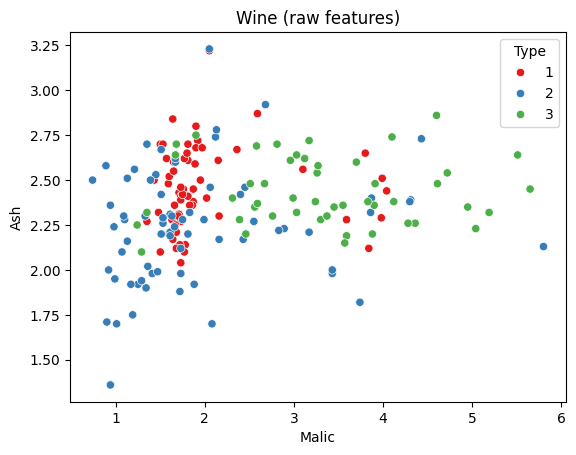

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy before PCA: 0.981


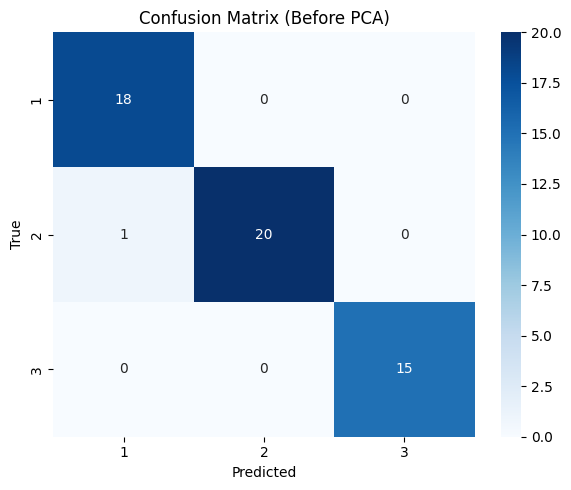

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Accuracy after PCA (2D): 0.944


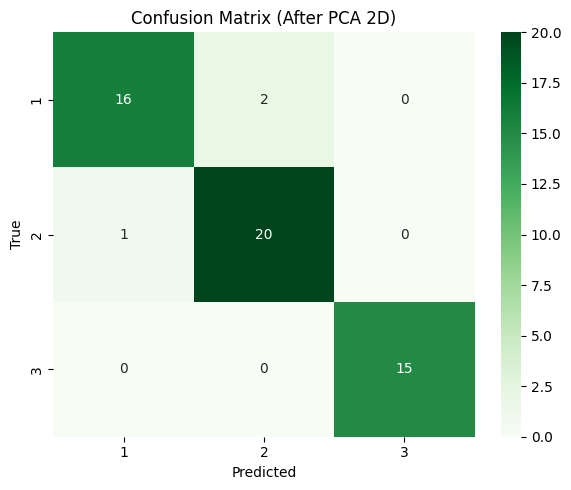

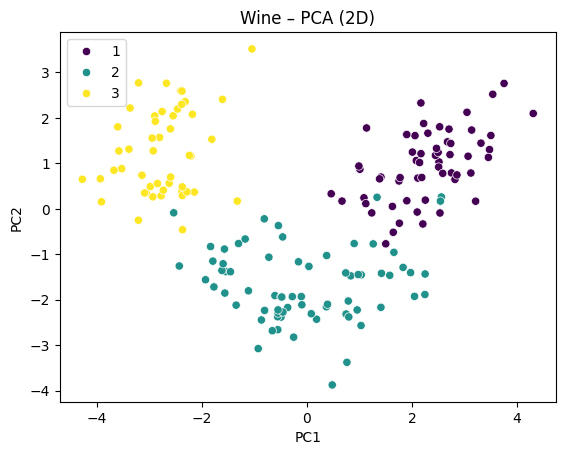

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix

# 1) Load data (from your CSV)
df = pd.read_csv("/content/wine.csv")

# Use 'Type' as the target column
X = df.drop(columns=['Type']).values
y = df['Type'].values
feature_names = df.drop(columns=['Type']).columns
target_names = np.unique(y)
#print(df.head(60))

# ---- Quick raw scatter (first two original features) ----
sns.scatterplot(x=df[feature_names[1]], y=df[feature_names[2]],
                hue=df['Type'], palette='Set1')
plt.title("Wine (raw features)")
plt.xlabel(feature_names[1])
plt.ylabel(feature_names[2])
plt.show()

# 2) Train/test split ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# 3) Multinomial Logistic Regression on ALL features ----
pipe_full = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000))
])
pipe_full.fit(X_train, y_train)
y_pred_full = pipe_full.predict(X_test)
acc_full = accuracy_score(y_test, y_pred_full)
cm_full = confusion_matrix(y_test, y_pred_full)

print(f"Accuracy before PCA: {acc_full:.3f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm_full, annot=True, fmt='d', cmap='Blues',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (Before PCA)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 4) Retrain Logistic Regression on PCA-transformed (2D) ----
pipe_pca2 = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=2)),
    ("clf", LogisticRegression(multi_class='multinomial', solver='lbfgs', max_iter=2000))
])
pipe_pca2.fit(X_train, y_train)
y_pred_pca2 = pipe_pca2.predict(X_test)
acc_pca2 = accuracy_score(y_test, y_pred_pca2)
cm_pca2 = confusion_matrix(y_test, y_pred_pca2)

print(f"Accuracy after PCA (2D): {acc_pca2:.3f}")

plt.figure(figsize=(6,5))
sns.heatmap(cm_pca2, annot=True, fmt='d', cmap='Greens',
            xticklabels=target_names, yticklabels=target_names)
plt.title("Confusion Matrix (After PCA 2D)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

# 5) PCA (2 components) for visualization ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca2 = PCA(n_components=2)
X_pca2 = pca2.fit_transform(X_scaled)

sns.scatterplot(x=X_pca2[:,0], y=X_pca2[:,1], hue=y, palette='viridis')
plt.title("Wine – PCA (2D)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
